In [45]:
import torch
import torch.nn as nn
import torchvision.transforms as T
from torch.optim import Adam
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader
import numpy as np
from tqdm.notebook import tqdm
import math

import logging


log = logging.getLogger(__name__)
logging.basicConfig(level=logging.DEBUG)


In [46]:
# create a patch embedding that split the image into batches and then flattens uit

class PatchEmbeddings(nn.Module):
    def __init__(self, d_model, image_size, patch_size, num_channels, debug=False):
        super().__init__()

        self.d_model = d_model
        self.image_size = image_size
        self.patch_size = patch_size
        self.num_channels = num_channels
        self.debug = debug


        self.linear_projection = nn.Conv2d(self.num_channels, self.d_model, kernel_size=self.patch_size, stride=self.patch_size)

    # B: Batch Size
    # C: Image Channels
    # H: Image Height
    # W: Image Width
    # P_col: Patch Column
    # P_row: Patch Row
    def forward(self, x):
      if self.debug:
            log.debug(f"Input shape: {x.shape}")
      x = self.linear_projection(x) # (B, C, H, W) -> (B, d_model, P_col, P_row)
      if self.debug:
            log.debug(f"After Conv2d: {x.shape}")

      x = x.flatten(2) # (B, d_model, P_col, P_row) -> (B, d_model, P)
      if self.debug:
            log.debug(f"After flatten: {x.shape}")


      x = x.transpose(1, 2) # (B, d_model, P) -> (B, P, d_model)
      if self.debug:
            log.debug(f"After transpose: {x.shape}")
      
      return x

In [47]:
# test the path embedding
test_model = PatchEmbeddings(
    d_model= 768,
    image_size=32,
    patch_size=4,
    num_channels=3, 
    debug=True
)

x = torch.randn(2, 3, 32, 32)
y = test_model(x)

DEBUG:__main__:Input shape: torch.Size([2, 3, 32, 32])
DEBUG:__main__:After Conv2d: torch.Size([2, 768, 8, 8])
DEBUG:__main__:After flatten: torch.Size([2, 768, 64])
DEBUG:__main__:After transpose: torch.Size([2, 64, 768])


In [48]:
class PositionalEncoding(nn.Module):
    """
    Adds a learnable CLS token and fixed sinusoidal positional encodings
    to a sequence of input embeddings.

    Args:
        d_model (int):
            Dimension of each embedding vector.
        max_seq_len (int):
            Maximum number of input tokens (excluding the CLS token).
    """

    def __init__(self, d_model: int, max_seq_len: int):
        super().__init__()

        self.d_model = d_model
        self.max_seq_len = max_seq_len

        # Learnable classification token - randomly initialized 
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))

        # Fixed positional encodings (includes one extra position for CLS token)
        positional_encoding = self.create_positional_encoding()
        self.register_buffer("pe", positional_encoding)

    def create_positional_encoding(self) -> torch.Tensor:
        """
        Create fixed sinusoidal positional encodings.    

        Returns:
            torch.Tensor:
                Positional encodings of shape
                (1, max_seq_len + 1, d_model), where the extra
                position corresponds to the CLS token.
        """
        # Position indices: [0, 1, ..., max_seq_len]
        position = torch.arange(self.max_seq_len + 1).unsqueeze(1)    

        # Scaling factor for the sinusoidal frequencies
        div_term = torch.exp(
            torch.arange(0, self.d_model, 2)
            * (-np.log(10000.0) / self.d_model)
        )    

        # Create the positional encoding matrix
        pe = torch.zeros(self.max_seq_len + 1, self.d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)    

        return pe.unsqueeze(0)

    def prepend_cls_token(self, x: torch.Tensor) -> torch.Tensor:
        """
        Prepend a learnable CLS token to each sequence in the batch.

        Args:
            x:
                Input tensor of shape (batch_size, seq_len, d_model).

        Returns:
            torch.Tensor:
                Tensor of shape (batch_size, seq_len + 1, d_model).
        """
        batch_size = x.size(0)
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        return torch.cat((cls_tokens, x), dim=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Add the CLS token and positional encodings.

        Args:
            x:
                Input embeddings of shape
                (batch_size, seq_len, d_model).

        Returns:
            torch.Tensor:
                Embeddings with CLS token and positional encodings added.
        """
        x = self.prepend_cls_token(x)
        x = x + self.pe[:, : x.size(1)]
        return x


In [49]:
class AttentionHead(nn.Module):
    def __init__(self, d_model, head_size, dropout=0.1):
        super().__init__()
        self.head_size = head_size

        # single projection is more efficient
        self.qkv = nn.Linear(d_model, 3 * head_size, bias=False)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        """
        x: (B, T, d_model)
        mask: optional (B, T, T) or (T, T)
        """

        B, T, _ = x.shape

        qkv = self.qkv(x)  # (B, T, 3 * head_size)
        Q, K, V = qkv.chunk(3, dim=-1)

        # attention scores
        attn = (Q @ K.transpose(-2, -1)) / math.sqrt(self.head_size)

        # optional masking (causal / padding)
        if mask is not None:
            attn = attn.masked_fill(mask == 0, float("-inf"))

        attn = F.softmax(attn, dim=-1)
        attn = self.dropout(attn)

        out = attn @ V
        return out

In [50]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()

        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"

        self.n_heads = n_heads
        self.head_dim = d_model // n_heads

        # single projection for all heads
        self.qkv = nn.Linear(d_model, 3 * d_model, bias=False)

        self.W_o = nn.Linear(d_model, d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        B, T, C = x.shape

        # QKV projection
        qkv = self.qkv(x)  # (B, T, 3*d_model)
        Q, K, V = qkv.chunk(3, dim=-1)

        # reshape into heads
        Q = Q.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        K = K.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        V = V.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        # attention
        attn = (Q @ K.transpose(-2, -1)) / math.sqrt(self.head_dim)

        if mask is not None:
            attn = attn.masked_fill(mask == 0, float("-inf"))

        attn = torch.softmax(attn, dim=-1)
        attn = self.dropout(attn)

        out = attn @ V  # (B, heads, T, head_dim)

        # merge heads
        out = out.transpose(1, 2).contiguous().view(B, T, C)

        return self.W_o(out)

In [51]:
import torch.nn as nn


class TransformerEncoder(nn.Module):
    def __init__(self, d_model, n_heads, r_mlp=4, dropout=0.1):
        super().__init__()

        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)

        self.mha = MultiHeadAttention(d_model, n_heads, dropout)
        
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model * r_mlp),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * r_mlp, d_model),
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):

        # Attention block
        x = x + self.dropout(self.mha(self.ln1(x), mask=mask))

        # Feed-forward block
        x = x + self.dropout(self.ffn(self.ln2(x)))

        return x

In [52]:
class VisionTransformer(nn.Module):
    def __init__(
        self,
        d_model,
        n_classes,
        img_size,
        patch_size,
        n_channels,
        n_heads,
        n_layers,
        dropout=0.1,
    ):
        super().__init__()

        assert img_size[0] % patch_size[0] == 0
        assert img_size[1] % patch_size[1] == 0
        assert d_model % n_heads == 0

        self.n_patches = (img_size[0] * img_size[1]) // (patch_size[0] * patch_size[1])
        self.seq_len = self.n_patches + 1  # CLS token

        # Patch + embedding
        self.patch_embedding = PatchEmbeddings(
            d_model, img_size, patch_size, n_channels
        )

        # CLS token
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))

        # Positional embedding (learnable is standard for ViT)
        self.pos_embedding = nn.Parameter(torch.randn(1, self.seq_len, d_model))

        # Transformer stack
        self.transformer = nn.ModuleList(
            [TransformerEncoder(d_model, n_heads, dropout=dropout) for _ in range(n_layers)]
        )

        self.norm = nn.LayerNorm(d_model)

        # classifier (NO softmax)
        self.classifier = nn.Linear(d_model, n_classes)

        self.dropout = nn.Dropout(dropout)

    def forward(self, images):
        B = images.shape[0]

        x = self.patch_embedding(images)

        # CLS token
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls, x), dim=1)

        # add position
        x = x + self.pos_embedding
        x = self.dropout(x)

        # transformer blocks
        for layer in self.transformer:
            x = layer(x)

        x = self.norm(x)

        # classify using CLS token
        return self.classifier(x[:, 0])

In [53]:
#  load the dataset
transform = T.Compose([
    T.RandomHorizontalFlip(),
    T.RandomCrop(32, padding=4),
    T.ToTensor(),
    T.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

train_dataset = CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [54]:
import torch

def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    elif torch.backends.mps.is_available():
        return torch.device("mps")
    else:
        return torch.device("cpu")

device = get_device()
print("Using device:", device)

Using device: mps


In [55]:
model = VisionTransformer(
    d_model=768,
    n_classes=10,
    img_size=(32, 32),
    patch_size=(4, 4),
    n_channels=3,
    n_heads=8,
    n_layers=6
).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

In [56]:
def train_one_epoch():
    model.train()
    total_loss = 0.0

    loop = tqdm(train_loader, desc="Training", leave=False)

    for inputs, labels in loop:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        loop.set_postfix(loss=loss.item())

    return total_loss / len(train_loader)

In [57]:
def evaluate():
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total

In [58]:
import torch.nn.functional as F

history = {"train_loss": [], "test_acc": []}
attn_snapshots = []   # one attention heatmap captured after each epoch

# Fix a single test image so we can track how attention changes over training
_fixed_image, _fixed_label = next(iter(test_loader))
_fixed_image = _fixed_image[[0]].to(device)   # shape (1, C, H, W)

def _snapshot_attention(model, image, layer_idx=-1):
    """Return a (H, W) numpy attention heatmap for one image (no grad)."""
    model.eval()
    cache = {}

    def hook(module, inputs, output):
        x = inputs[0]
        B, T, C = x.shape
        qkv = module.qkv(x)
        Q, K, _ = qkv.chunk(3, dim=-1)
        Q = Q.view(B, T, module.n_heads, module.head_dim).transpose(1, 2)
        K = K.view(B, T, module.n_heads, module.head_dim).transpose(1, 2)
        attn = torch.softmax(
            (Q @ K.transpose(-2, -1)) / math.sqrt(module.head_dim), dim=-1
        )
        cache["attn"] = attn.detach().cpu()

    handle = model.transformer[layer_idx].mha.register_forward_hook(hook)
    with torch.no_grad():
        model(image)
    handle.remove()

    attn = cache["attn"][0]                     # (heads, T, T)
    patch_scores = attn[:, 0, 1:].mean(dim=0)   # CLS→patches, mean over heads
    grid = int(math.sqrt(patch_scores.numel()))
    heatmap = F.interpolate(
        patch_scores.view(1, 1, grid, grid),
        size=(image.shape[-2], image.shape[-1]),
        mode="bilinear", align_corners=False
    ).squeeze().numpy()
    return heatmap

# ── Training loop ────────────────────────────────────────────────────────────
epochs = 10

for epoch in tqdm(range(epochs), desc="Epochs"):
    train_loss = train_one_epoch()
    test_acc   = evaluate()

    history["train_loss"].append(train_loss)
    history["test_acc"].append(test_acc)

    # Capture attention snapshot on the fixed image after each epoch
    attn_snapshots.append(_snapshot_attention(model, _fixed_image))

    print(f"Epoch {epoch+1}/{epochs}  |  Loss: {train_loss:.4f}  |  Acc: {test_acc:.4f}")


Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

Training:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 1/10  |  Loss: 1.9675  |  Acc: 0.3313


Training:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 2/10  |  Loss: 1.8498  |  Acc: 0.3288


Training:   0%|          | 0/782 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt

def plot_learning_curves(history):
    epochs_range = range(1, len(history["train_loss"]) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle("Learning Curves", fontsize=14)

    ax1.plot(epochs_range, history["train_loss"], marker="o", color="steelblue", label="Train Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title("Training Loss")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(epochs_range, history["test_acc"], marker="o", color="coral", label="Test Accuracy")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.set_title("Test Accuracy")
    ax2.set_ylim(0, 1)
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_learning_curves(history)


DEBUG:matplotlib:matplotlib data path: /Users/roksana/Developement/AI_Researcher_Learning_Path/.venv/lib/python3.12/site-packages/matplotlib/mpl-data
DEBUG:matplotlib:CONFIGDIR=/Users/roksana/.matplotlib
DEBUG:matplotlib:interactive is False
DEBUG:matplotlib:platform is darwin
DEBUG:matplotlib:CACHEDIR=/Users/roksana/.matplotlib
DEBUG:matplotlib.font_manager:Using fontManager instance from /Users/roksana/.matplotlib/fontlist-v390.json
DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.font_manager:findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/Users/roksana/Developement/AI_Researcher_Learning_Path/.venv/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizOneSymReg.ttf', name='STIXSizeOneSym', style=

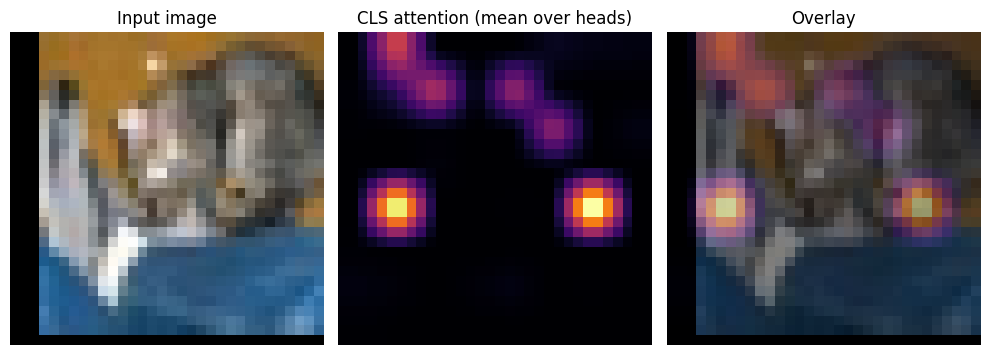

Label index: 3


In [43]:
import math
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

CIFAR10_CLASSES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

def denormalize(img_tensor):
    return (img_tensor * 0.5 + 0.5).clamp(0, 1)

@torch.no_grad()
def show_vit_attention_heatmap(model, dataloader, device, layer_idx=-1, head_idx=None, sample_idx=0):
    """
    Visualize CLS-token attention heatmap on a test image.

    Args:
        layer_idx : transformer block to inspect (-1 = last)
        head_idx  : None = average over all heads, int = single head
        sample_idx: which image in the first test batch to show
    """
    model.eval()

    batch = next(iter(dataloader))
    images, labels = batch
    images = images.to(device)

    cache = {}

    def mha_hook(module, inputs, output):
        x = inputs[0]
        B, T, C = x.shape
        qkv = module.qkv(x)
        Q, K, _ = qkv.chunk(3, dim=-1)
        Q = Q.view(B, T, module.n_heads, module.head_dim).transpose(1, 2)
        K = K.view(B, T, module.n_heads, module.head_dim).transpose(1, 2)
        attn = torch.softmax((Q @ K.transpose(-2, -1)) / math.sqrt(module.head_dim), dim=-1)
        cache["attn"] = attn.detach().cpu()

    handle = model.transformer[layer_idx].mha.register_forward_hook(mha_hook)
    logits = model(images)
    handle.remove()

    b = sample_idx
    attn = cache["attn"]

    # CLS (position 0) attending to patch tokens (positions 1..)
    cls_to_patches = attn[b, :, 0, 1:]   # (n_heads, n_patches)
    patch_scores = cls_to_patches.mean(dim=0) if head_idx is None else cls_to_patches[head_idx]
    title_suffix = "mean over heads" if head_idx is None else f"head {head_idx}"

    grid_size = int(math.sqrt(patch_scores.numel()))
    heatmap = patch_scores.view(grid_size, grid_size).unsqueeze(0).unsqueeze(0)
    heatmap = F.interpolate(heatmap, size=(images.shape[-2], images.shape[-1]),
                            mode="bilinear", align_corners=False).squeeze().numpy()

    img = denormalize(images[b].cpu()).permute(1, 2, 0).numpy()

    pred_class  = CIFAR10_CLASSES[logits[b].argmax().item()]
    true_class  = CIFAR10_CLASSES[labels[b].item()]

    fig, axes = plt.subplots(1, 3, figsize=(11, 4))
    fig.suptitle(f"True: {true_class}  |  Predicted: {pred_class}", fontsize=13)

    axes[0].imshow(img);           axes[0].set_title("Input image");           axes[0].axis("off")
    axes[1].imshow(heatmap, cmap="inferno"); axes[1].set_title(f"Attention ({title_suffix})"); axes[1].axis("off")
    axes[2].imshow(img);           axes[2].imshow(heatmap, cmap="inferno", alpha=0.5)
    axes[2].set_title("Overlay");  axes[2].axis("off")

    plt.tight_layout()
    plt.show()

# ── Run after training ──────────────────────────────────────────────────────
# Change sample_idx to pick a different test image (0-63 within the first batch)
show_vit_attention_heatmap(model, test_loader, device, layer_idx=-1, head_idx=None, sample_idx=0)


In [ ]:
import matplotlib.pyplot as plt

def plot_attention_evolution(attn_snapshots, fixed_image, fixed_label):
    """
    Show attention overlays side-by-side for every epoch captured in attn_snapshots.
    Top row: epochs 1-5   |   Bottom row: epochs 6-10
    """
    n = len(attn_snapshots)
    cols = min(n, 5)
    rows = (n + cols - 1) // cols

    true_class = CIFAR10_CLASSES[fixed_label.item()]
    img = denormalize(fixed_image[0].cpu()).permute(1, 2, 0).numpy()

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    fig.suptitle(
        f"Attention Evolution During Training  |  Image: {true_class}\n"
        "(CLS → patches, last block, mean over heads)",
        fontsize=12
    )

    for i, ax in enumerate(axes.flat):
        if i < n:
            ax.imshow(img)
            ax.imshow(attn_snapshots[i], cmap="inferno", alpha=0.55)
            ax.set_title(f"Epoch {i+1}", fontsize=10)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

plot_attention_evolution(attn_snapshots, _fixed_image, _fixed_label)
